### Notebook 5: Grouping Events

In the last notebook, we averaged the signals from all LFEs.  But we may want to sort the events into groups and just average within those groups.  Then we can compare the stacks obtained from various groups.  

This notebook gives one approach to grouping: events that occur early or late in a slow slip event. 

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

import os,sys
sys.path.append(os.path.join(os.environ['PYFILES']))
import LFEAnalysis as lfeanalysis
lfeanalysis.reload_all(lfeanalysis)

### 1. Initialize and read detection info

In [2]:
# as usual, we need to initialize an analysis object
lf=lfeanalysis.lfeanalyse(fnum=156,region='Cascadia',catalog='Bostock')

# and we need the LFE times
# we're using Bostock et al (2015)'s catalog for southern Vancouver Island, in Cascadia
lf.read_detection_info()

In [3]:
# note that we now have the times of all LFEs in this family
print(lf.tms)
print(lf.tms.shape)

[UTCDateTime(2003, 2, 26, 14, 45, 28, 500000)
 UTCDateTime(2003, 3, 2, 1, 29, 8, 775000)
 UTCDateTime(2003, 3, 2, 18, 45, 51, 900000) ...
 UTCDateTime(2013, 10, 5, 0, 6, 37, 700000)
 UTCDateTime(2013, 10, 7, 0, 37, 32, 950000)
 UTCDateTime(2013, 10, 10, 6, 24, 43, 75000)]
(1658,)


In [4]:
# and the times of all LFEs, including all families
print(lf.atms)
print(lf.atms.shape)

[UTCDateTime(2003, 2, 28, 5, 52, 27, 900000)
 UTCDateTime(2003, 3, 2, 16, 24, 26, 150000)
 UTCDateTime(2003, 3, 2, 22, 16, 58, 875000) ...
 UTCDateTime(2013, 10, 2, 23, 11, 3, 875000)
 UTCDateTime(2013, 10, 4, 1, 40, 58, 300000)
 UTCDateTime(2013, 10, 5, 3, 27, 29, 200000)]
(213811,)


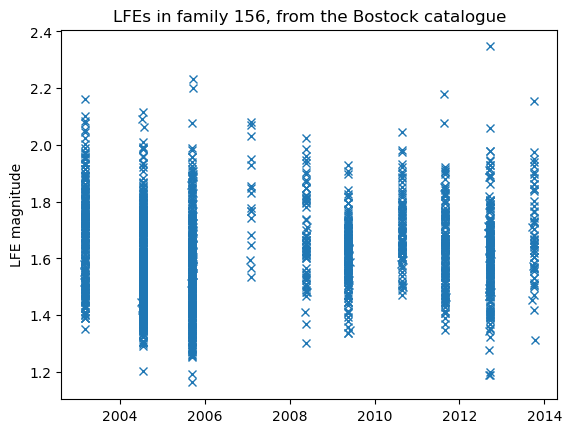

In [5]:
plt.plot([tm.datetime for tm in lf.tms],lf.mags,marker='x',linestyle='none');
plt.ylabel('LFE magnitude');
plt.title('LFEs in family {:d}, from the {:s} catalogue'.format(lf.fnum,lf.catalog));

### 2. Note the large slow slip events

To group, we may first note that the LFEs are grouped into slow slip events.  In Cascadia, slow slip events (SSEs) last about a month and occur around once a year.  The catalogue we're using uses only events that occurred within the large SSEs in Cascadia.  They didn't look for LFEs between the large events.

We'd like to automatically identify the SSEs in the catalogue.  The function lf.identify_sse_times takes a very simple (and artificial) approach to do this.  Since we know there are 10 SSEs with large gaps between them, we just look for the 9 largest time gaps between LFEs to separate the events.  If you're working somewhere where there isn't a large gap between slow slip events, lf.identify_sse_times wouldn't work, and you'll need another approach.  In this case, you just want an approach to set lf.sse_times and lf.Nsse, perhaps manually.

In [6]:
# identify the times
lf.identify_sse_times(n_events=10)

In [7]:
# we've now created two variables

# the number of SSEs
print('Number of SSEs: ',lf.Nsse)

# and the time ranges of these events
print(lf.sse_tlms.shape)
print('Event 3 occurs between ',lf.sse_tlms[2,:])

Number of SSEs:  10
(10, 2)
Event 3 occurs between  [UTCDateTime(2005, 9, 2, 0, 0) UTCDateTime(2005, 9, 26, 0, 0)]


### 3. Compute LFE rates as a function of time

We may want to know how the number of LFEs per minute or hour changes over the course of a slow slip event.  The function lf.compute_lfe_rates computes the number of LFEs in bins with duration bin_duration, spaced every bin_spacing.  By default, the spacing is set to one quarter of the window length.


[UTCDateTime(2003, 2, 25, 2, 30) UTCDateTime(2003, 2, 25, 3, 45)
 UTCDateTime(2003, 2, 25, 5, 0) ... UTCDateTime(2013, 10, 13, 18, 30)
 UTCDateTime(2013, 10, 13, 19, 45) UTCDateTime(2013, 10, 13, 21, 0)]
[0. 0. 0. ... 0. 0. 0.]


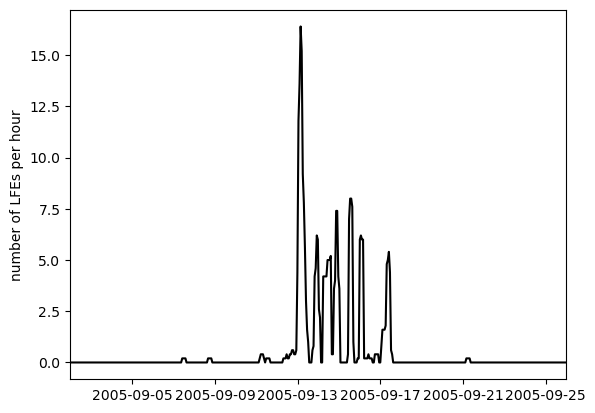

In [8]:
# here, compute the number of LFEs per 5-hour period
lf.compute_lfe_rates(bin_duration=5*3600)

# the centres of the time windows considered are in lf.tcent
print(lf.tcent)

# and the rates (per hour) are in lf.lferate
print(lf.lferate)

plt.plot([tm.datetime for tm in lf.tcent],lf.lferate,color='black',marker='none',linestyle='-')
plt.xlim(lf.sse_tlms[2,:]);
plt.ylabel('number of LFEs per hour');

### 4. Group LFEs within a slow slip event

We may wish to identify LFEs that occur early in a slow slip event vs later in a slow slip event---at least within a family.

To do so, we first determine a family "start time" for each SSE.  This is the time when the LFE rate _first_ reaches some fraction of the maximum.   The function lf.select_start_times saves these start times in lf.start_times

In [9]:
# to do so, we first determine a family "start time": 
# here the time when the LFE rate reaches half the maximum LFE rate
lf.select_start_times(start_rate=0.5)

print(lf.start_times)

[UTCDateTime(2003, 3, 4, 17, 0) UTCDateTime(2004, 7, 16, 3, 45)
 UTCDateTime(2005, 9, 12, 22, 30) UTCDateTime(2007, 1, 31, 13, 0)
 UTCDateTime(2008, 5, 18, 17, 45) UTCDateTime(2009, 5, 17, 12, 0)
 UTCDateTime(2010, 8, 25, 20, 0) UTCDateTime(2011, 8, 27, 0, 15)
 UTCDateTime(2012, 9, 15, 4, 30) UTCDateTime(2013, 10, 4, 14, 30)]


Then we group the events by time since the start time.  The function lf.group_events_bytime accepts the times that bound each group, in days.

It saves the indices of the grouped events in a dictionary lf.groups.  If there are 2 groups, they are called 'early' and 'late'.  If there are 3 groups, they are called 'early', 'middle', and 'late'.  If there are more groups, they are numbered.

Each element of the dictionary contains the indices of the LFEs in that group.

In [10]:
# and then group the events by time since the start time
# here we have two groups: 0-0.75 days since the start time and 0.75-3 days since the start time
lf.group_events_bytime(tsplits=[0,0.75,3])

In [11]:
# we now have a dictionary 
print('The groups are ',list(lf.groups.keys()))

# here there are two groups: 'early' and 'late'
# the integers listed are the indices of the events in each group, 
# so the times of the first 10 LFEs in the early group are
print('The indices of the first 10 LFEs in the early group are\n',lf.groups['early'][0:10])
print('\nThe times of the first 10 LFEs in the early group are\n',lf.tms[lf.groups['early'][0:10]])

The groups are  ['early', 'late']
The indices of the first 10 LFEs in the early group are
 [ 4  5  6  7  8  9 10 11 12 13]

The times of the first 10 LFEs in the early group are
 [UTCDateTime(2003, 3, 4, 18, 37, 13, 25000)
 UTCDateTime(2003, 3, 4, 19, 10, 57, 650000)
 UTCDateTime(2003, 3, 4, 19, 15, 8, 850000)
 UTCDateTime(2003, 3, 4, 19, 42, 44, 425000)
 UTCDateTime(2003, 3, 4, 19, 53, 38, 350000)
 UTCDateTime(2003, 3, 4, 19, 59, 34, 100000)
 UTCDateTime(2003, 3, 4, 20, 1, 25, 625000)
 UTCDateTime(2003, 3, 4, 20, 2, 34, 175000)
 UTCDateTime(2003, 3, 4, 20, 18, 0, 200000)
 UTCDateTime(2003, 3, 4, 20, 19, 23, 225000)]


### 5. Examine the groups

We can now see how the grouping has gone.  The function lf.plot_rate will plot the LFEs during one year's SSE and colour them by group, but it's a bit messy.

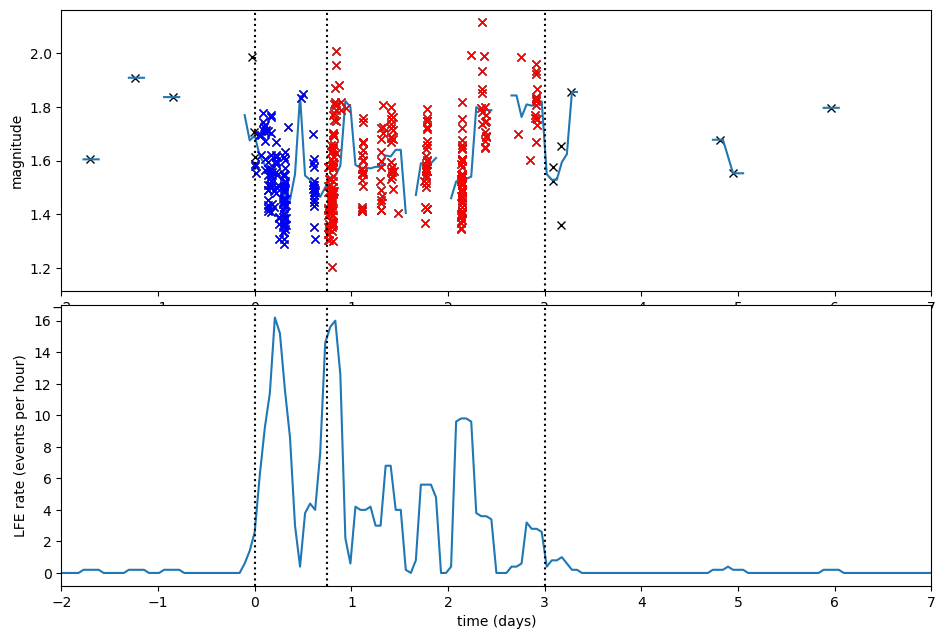

In [12]:
# it may be useful to plot the LFE properties and the LFE rate through time during an SSE
lf.plot_rate(iev=2004)